Environment ready!
NumPy: 2.5.3
pandas: 3.0.6
scikit-learn: 1.9.1


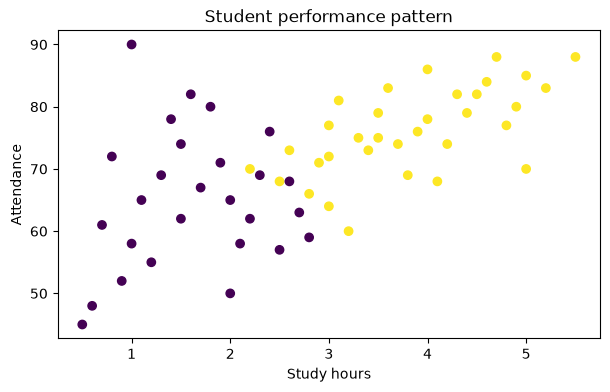

X shape: (60, 3)
y shape: (60,)
Training rows: 48
Testing rows : 12
Model trained!
Prediction:
[0 1 1 1 1 0 1 0 1 0 1 0]
X_test:
    study_hours  attendance  assignments
34          0.9          52            6
46          4.1          68            9
15          4.2          74            8
25          5.0          70            9
54          5.2          83           10
45          1.6          82            4
42          4.9          80           10
26          1.7          67            6
48          3.3          75            7
17          1.8          80            5
27          3.6          83            8
19          2.0          50            7
test accuracy:100.00%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)


df = pd.read_csv("day3.csv")
df.head()

df.groupby("result")[["study_hours","attendance","assignments"]].mean()

plt.figure(figsize=(7,4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"])
plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()



X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]



print("X shape:", X.shape)
print("y shape:", y.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

predictions= model.predict(X_test)
print("Prediction:")
print(predictions)
print("X_test:")
print(X_test)

accuracy=accuracy_score(y_test,predictions)
print(f"test accuracy:{accuracy:.2%}")

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# =====================================================================
# STEP 1: Prepare Sample Data (In-Memory Dataset)
# =====================================================================
# We define simple email subjects and label them as 0 (Ham/Safe) or 1 (Spam)
emails = [
    "Meeting schedule for tomorrow project review",  # Safe (0)
    "WIN FREE CASH NOW! CLICK HERE!",  # Spam (1)
    "Please send the engineering lab report by Friday",  # Safe (0)
    "Claim your free prize money today",  # Spam (1)
    "Urgent account verification required",  # Safe (0)
    "CONGRATULATIONS! You won a brand new car",  # Spam (1)
]

labels = [0, 1, 0, 1, 0, 1]  # 0 = Normal Email, 1 = Spam Email

# =====================================================================
# STEP 2: Feature Extraction (Convert Text to Numbers)
# =====================================================================
# Machine Learning algorithms work on numbers, not raw text.
# CountVectorizer counts how many times each word appears in each email.
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# =====================================================================
# STEP 3: Train the Machine Learning Model
# =====================================================================
# We use Naive Bayes, a classic, fast algorithm for text classification.
model = MultinomialNB()
model.fit(X, labels)

print("--- Model Training Complete! ---\n")

# =====================================================================
# STEP 4: Test the Model on Unseen Email Subjects
# =====================================================================
new_emails = [
    "Submit your lab assignment tomorrow",  # Expected: Safe
    "Win a free prize and cash bonus now",  # Expected: Spam
]

# Convert new text to the exact same numerical format
X_new = vectorizer.transform(new_emails)

# Make predictions
predictions = model.predict(X_new)

# Display Results
for email, pred in zip(new_emails, predictions):
    status = "SPAM 🚨" if pred == 1 else "SAFE / NORMAL 🟢"
    print(f"Email   : '{email}'")
    print(f"Result  : {status}\n")

--- Model Training Complete! ---

Email   : 'Submit your lab assignment tomorrow'
Result  : SAFE / NORMAL 🟢

Email   : 'Win a free prize and cash bonus now'
Result  : SPAM 🚨



Dataset:
   Temperature_C  Voltage_V  Power_Consumption_W
0             25        5.0                 10.2
1             30        5.1                 11.5
2             35        5.0                 12.8
3             40        5.2                 14.1
4             45        5.1                 15.7
5             50        5.3                 17.2
6             55        5.2                 18.9
7             60        5.4                 20.5
8             65        5.3                 22.1
9             70        5.5                 24.0

Slope: 0.30642424242424254
Intercept: 2.1448484848484792

Predicted power consumption at 75°C: 25.126666666666672 W


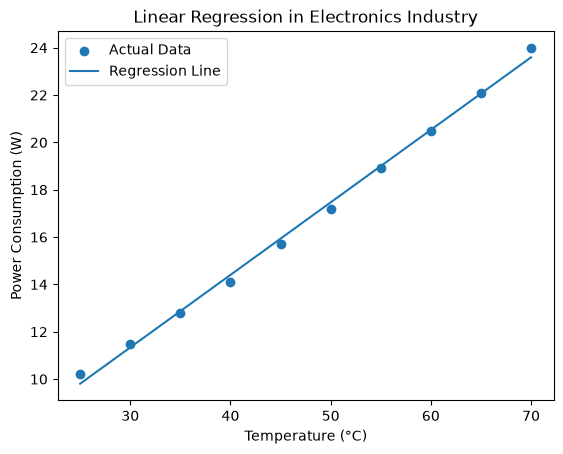

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Read the CSV file
data = pd.read_csv("electronics_linear_regression_data.csv")

print("Dataset:")
print(data)

# Input feature: Temperature
X = data[["Temperature_C"]]

# Target: Power Consumption
y = data["Power_Consumption_W"]

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Predict power consumption
y_pred = model.predict(X)

# Display model values
print("\nSlope:", model.coef_[0])
print("Intercept:", model.intercept_)

# Predict power consumption at 75°C
temperature = pd.DataFrame([[75]], columns=["Temperature_C"])
prediction = model.predict(temperature)

print("\nPredicted power consumption at 75°C:",
      prediction[0], "W")

# Plot actual data and regression line
plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, label="Regression Line")

plt.xlabel("Temperature (°C)")
plt.ylabel("Power Consumption (W)")
plt.title("Linear Regression in Electronics Industry")
plt.legend()
plt.show()

Original Dataset:
    Temperature  Voltage  Current  Power
0            30      5.0      1.0    5.0
1            32      5.1      1.1    5.6
2            31      5.0      1.0    5.0
3            29      5.1      0.9    4.6
4            33      5.2      1.1    5.7
5            35      5.1      1.2    6.1
6            34      5.2      1.1    5.7
7            36      5.1      1.2    6.1
8            45      5.0      1.5    7.5
9            47      4.9      1.6    7.8
10           46      5.0      1.5    7.5
11           48      4.9      1.7    8.3
12           70      5.8      2.5   14.5
13           72      5.9      2.6   15.3
14           75      6.0      2.7   16.2

Dataset after clustering:
    Temperature  Voltage  Current  Power  Cluster
0            30      5.0      1.0    5.0        2
1            32      5.1      1.1    5.6        2
2            31      5.0      1.0    5.0        2
3            29      5.1      0.9    4.6        2
4            33      5.2      1.1    5.7        2

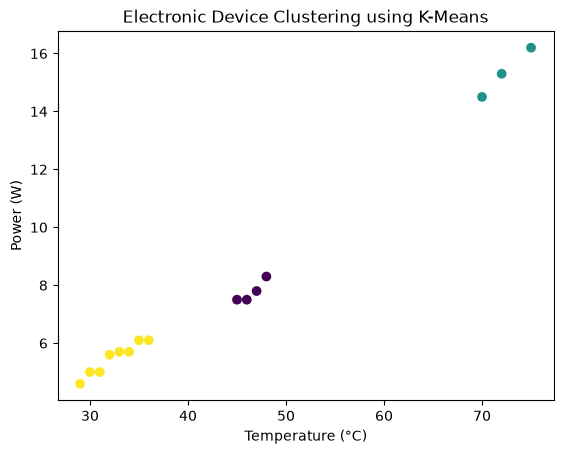

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Create electronic device dataset
data = {
    "Temperature": [30, 32, 31, 29, 33, 35, 34, 36,
                    45, 47, 46, 48, 70, 72, 75],

    "Voltage": [5.0, 5.1, 5.0, 5.1, 5.2, 5.1, 5.2, 5.1,
                5.0, 4.9, 5.0, 4.9, 5.8, 5.9, 6.0],

    "Current": [1.0, 1.1, 1.0, 0.9, 1.1, 1.2, 1.1, 1.2,
                1.5, 1.6, 1.5, 1.7, 2.5, 2.6, 2.7],

    "Power": [5.0, 5.6, 5.0, 4.6, 5.7, 6.1, 5.7, 6.1,
              7.5, 7.8, 7.5, 8.3, 14.5, 15.3, 16.2]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)

# Select features
X = df[["Temperature", "Voltage", "Current", "Power"]]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
model = KMeans(n_clusters=3, random_state=42, n_init=10)
model.fit(X_scaled)

# Add cluster number
df["Cluster"] = model.labels_

print("\nDataset after clustering:")
print(df)

# Display cluster centers
print("\nCluster Centers:")
print(model.cluster_centers_)

# Visualize Temperature vs Power
plt.scatter(
    df["Temperature"],
    df["Power"],
    c=df["Cluster"]
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Power (W)")
plt.title("Electronic Device Clustering using K-Means")
plt.show()